In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/all_goalkeepers.csv')
print(df.shape)
df.head()

(174, 27)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,GA,GA90,SoTA,Saves,Save_pct,W,D,L,CS,CS%,PKatt,PKA,PKsv,PKm,PK_Save_pct,league
0,1,Ryan Allsop,eng ENG,GK,Birmingham City,33,1992,11,11,990.0,11.0,15,1.36,34,19,55.9,3,3,5,2,18.2,1,1,0,0,0.0,Championship
1,2,Nathan Baxter,eng ENG,GK,Watford,26,1998,7,6,585.0,6.5,9,1.38,20,11,55.0,3,2,1,0,0.0,0,0,0,0,NaN,Championship
2,3,Gavin Bazunu,ie IRL,GK,Stoke City,23,2002,6,6,540.0,6.0,8,1.33,19,11,57.9,1,2,3,2,33.3,0,0,0,0,NaN,Championship
3,4,Gavin Bazunu,ie IRL,GK,Southampton,23,2002,19,19,NaN,19.0,28,1.47,72,44,61.1,7,6,6,3,15.8,1,1,0,0,0.0,Championship
4,5,James Beadle,eng ENG,GK,Birmingham City,21,2004,35,35,NaN,35.0,41,1.17,129,88,68.2,14,10,11,8,22.9,2,1,1,0,50.0,Championship


In [2]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
Rk              0
Player          0
Nation          1
Pos             0
Squad           0
Age             0
Born            0
MP              0
Starts          0
Min            98
90s             0
GA              0
GA90            0
SoTA            0
Saves           0
Save_pct        2
W               0
D               0
L               0
CS              0
CS%             3
PKatt           0
PKA             0
PKsv            0
PKm             0
PK_Save_pct    67
league          0
dtype: int64


In [8]:
MIN_MATCHES = 10

qualified_keepers = df[df['MP'] >= MIN_MATCHES].copy()
qualified_keepers[['Age', 'MP', 'Min', 'Save_pct', 'CS%', 'GA90']].describe()

,Age,MP,Min,Save_pct,CS%,GA90
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,26.514286,27.219048,2431.628571,67.072381,25.962857,1.352762
std,4.474531,10.076611,912.619110,5.719324,10.418643,0.326159
min,18.000000,10.000000,813.000000,48.900000,0.000000,0.800000
25%,23.000000,18.000000,1620.000000,64.000000,18.200000,1.170000
50%,27.000000,31.000000,2700.000000,67.400000,25.000000,1.330000
75%,29.000000,34.000000,3060.000000,70.500000,33.300000,1.500000
max,38.000000,46.000000,4140.000000,80.100000,50.000000,2.800000


## Top Keeper saves by %

In [9]:
top_savers = qualified_keepers.sort_values('Save_pct', ascending=False).reset_index(drop=True)
top_savers.index = top_savers.index + 1

top_savers[['Player', 'Squad', 'league', 'Age', 'MP', 'Save_pct', 'CS%']].head(15)

,Player,Squad,league,Age,MP,Save_pct,CS%
1,Lorenzo Palmisani,Frosinone,Serie B,21,38,80.1,39.5
2,Simon Ngapandouetnbu,Montpellier,Ligue 2,22,31,79.4,38.7
3,Filip Stankovic,Venezia,Serie B,23,38,77.2,42.1
4,Jesse Joronen,Palermo,Serie B,32,35,76.9,45.7
5,Daniel Peretz,Southampton,Championship,25,20,76.3,35.0
6,Quentin Braat,Rodez AF,Ligue 2,28,34,75.9,20.6
7,Max Crocombe,Millwall,Championship,31,23,75.7,39.1
8,Demba Thiam,Monza,Serie B,27,38,75.4,42.1
9,Viktor Johansson,Stoke City,Championship,26,25,74.5,32.0
10,Leandro Chichizola,Modena,Serie B,35,33,73.8,42.4


## Save % vs Goals Conceded per 90

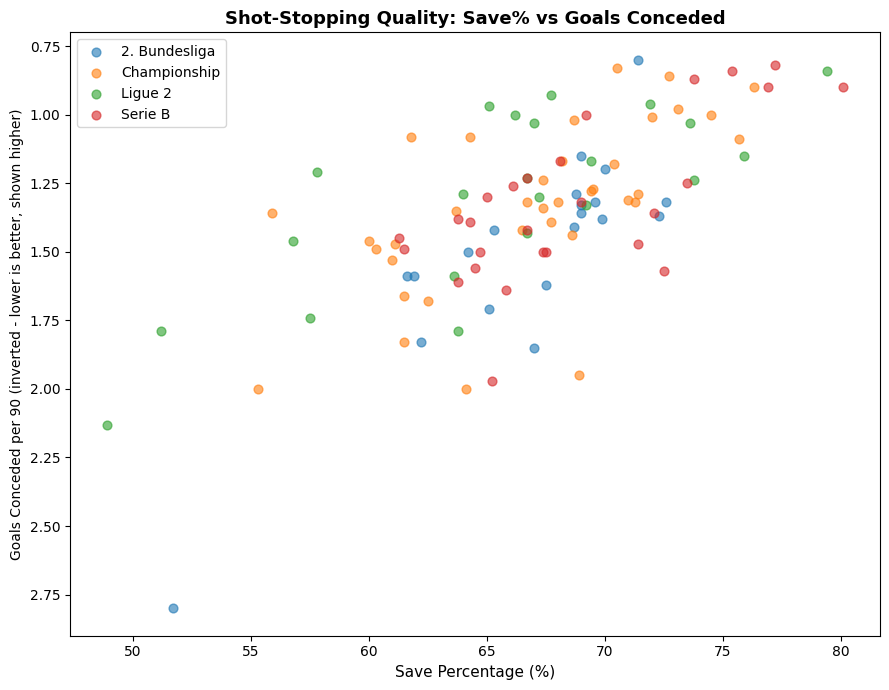

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

for league_name, group in qualified_keepers.groupby('league'):
    ax.scatter(group['Save_pct'], group['GA90'], label=league_name, alpha=0.6, s=40)

# flip GA90 so "better" is up on both axes, making top-right = elite keepers
ax.invert_yaxis()

ax.set_xlabel('Save Percentage (%)', fontsize=11)
ax.set_ylabel('Goals Conceded per 90 (inverted - lower is better, shown higher)', fontsize=10)
ax.set_title('Shot-Stopping Quality: Save% vs Goals Conceded', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## Save % by League

/var/folders/g5/_5kss0391hb12vcfrdb95x4h0000gn/T/ipykernel_93797/4252733598.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


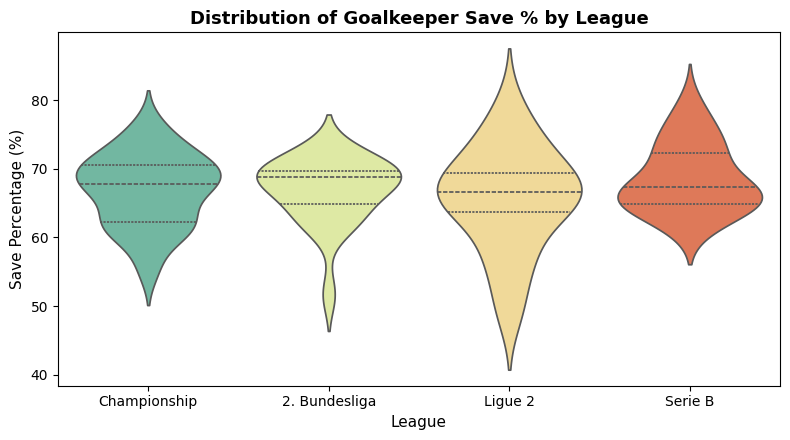

In [13]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.violinplot(
    data=qualified_keepers,
    x='league', y='Save_pct',
    palette='Spectral_r',
    inner='quartile',
    ax=ax
)

ax.set_xlabel('League', fontsize=11)
ax.set_ylabel('Save Percentage (%)', fontsize=11)
ax.set_title('Distribution of Goalkeeper Save % by League', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

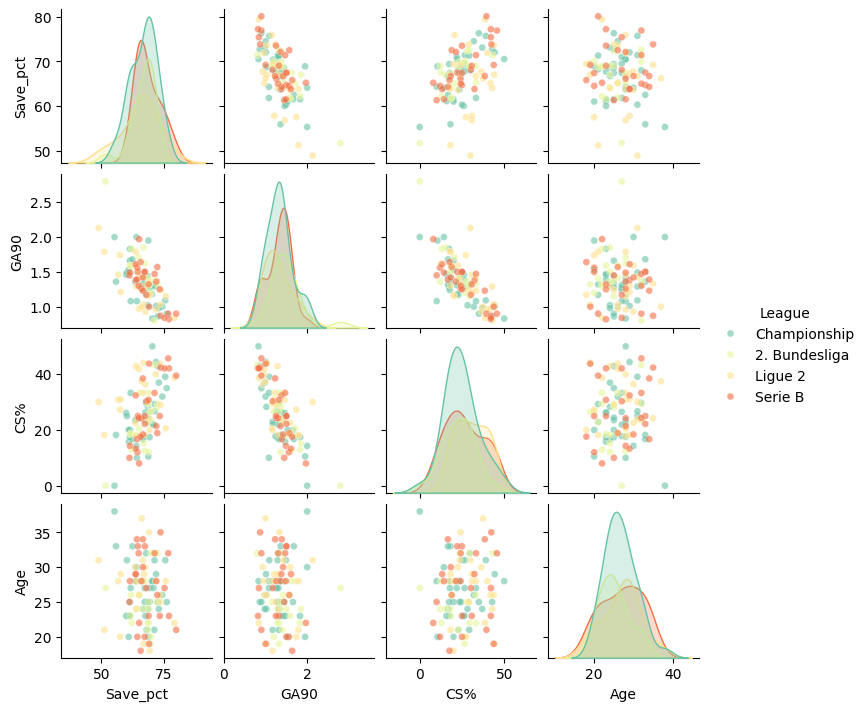

In [14]:
pairplot_cols = ['Save_pct', 'GA90', 'CS%', 'Age', 'league']

plot_data = qualified_keepers[pairplot_cols].rename(columns={'league': 'League'})

sns.pairplot(
    plot_data,
    hue='League',
    palette='Spectral_r',
    plot_kws={'alpha': 0.6, 's': 25, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kind='kde',
    height=1.8,
)
plt.show()